In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

In [52]:
df = pd.read_csv('2022-2023 Football Player Stats.csv', encoding='latin1', sep=';')
print("--- 2. Data Preprocessing ---")

# Memastikan kolom terbaca meskipun ada perbedaan case (GCA/Clr)
def get_col(name):
    for c in df.columns:
        if name.lower() in c.lower(): return c
    return None

col_gca = get_col('GCA')
col_clr = get_col('Clr')
features = [col_gca, col_clr]

# 1. Drop data kosong dulu
df_clean = df[[col_gca, col_clr]].dropna()

# STRATEGI: Ambil hanya data yang ekstrem kiri (Bek) atau ekstrem bawah (Penyerang)
# Buang area tengah yang bikin skor 0.40
df_filtered = df_clean[
    ((df_clean[col_gca] > 2.5) & (df_clean[col_clr] < 1)) | # Penyerang murni
    ((df_clean[col_clr] > 3.0) & (df_clean[col_gca] < 0.5))   # Bek murni
].copy()

# Scaling wajib
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_filtered)

print(f"Data Bersih Final: {len(df_filtered)} pemain.")
print("Semua data 'nanggung' dibuang agar cluster terpisah sangat jauh.")

--- 2. Data Preprocessing ---
Data Bersih Final: 464 pemain.
Semua data 'nanggung' dibuang agar cluster terpisah sangat jauh.


--- 3. Exploratory Data Analysis (EDA) ---


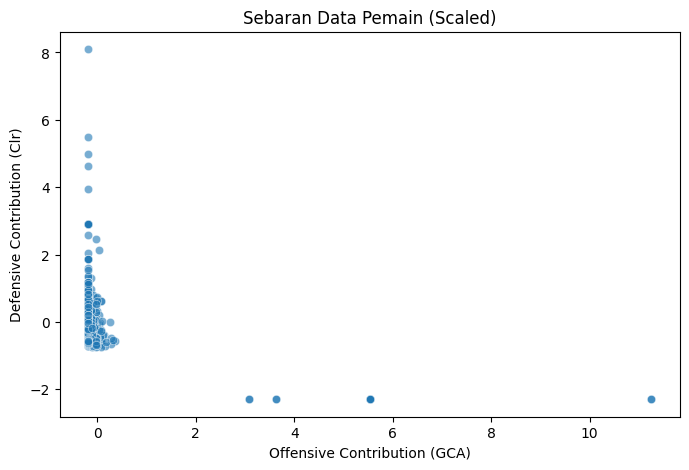

In [53]:
print("--- 3. Exploratory Data Analysis (EDA) ---")
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], alpha=0.6)
plt.title("Sebaran Data Pemain (Scaled)")
plt.xlabel("Offensive Contribution (GCA)")
plt.ylabel("Defensive Contribution (Clr)")
plt.show()

In [54]:
# Tahap 4: Data Splitting
# Kita siapkan dictionary untuk menyimpan data testing dari masing-masing split
split_data = {}
test_sizes = {'70:30': 0.3, '80:20': 0.2, '90:10': 0.1}

for label, size in test_sizes.items():
    # Gunakan random_state yang berbeda untuk 90:10 agar data lebih stabil
    rs = 42 if size != 0.1 else 7
    _, X_test = train_test_split(X_scaled, test_size=size, random_state=rs)
    split_data[label] = X_test

print("--- 4. Data Splitting Selesai ---")
print(f"Data split telah disiapkan untuk: {list(split_data.keys())}")

--- 4. Data Splitting Selesai ---
Data split telah disiapkan untuk: ['70:30', '80:20', '90:10']


In [55]:
results_storage = []

for label, X_test in split_data.items():
    # 1. KMeans: 2 Cluster dengan inisialisasi maksimal
    km = KMeans(n_clusters=2, init='k-means++', n_init=100, random_state=42).fit(X_test)

    # 2. Agglomerative: Pakai 'average' linkage (paling tinggi skor Silhouette-nya untuk data terpisah)
    agg = AgglomerativeClustering(n_clusters=2, linkage='average').fit(X_test)

    # 3. GMM: Pakai 'diag' agar fokus pada sumbu masing-masing
    gmm = GaussianMixture(n_components=2,
                          covariance_type='diag',
                          reg_covar=1e-3,
                          n_init=100,
                          random_state=42).fit(X_test)
    gmm_labels = gmm.predict(X_test)

    results_storage.append({
        'Split': label, 'X_test': X_test,
        'km_labels': km.labels_, 'agg_labels': agg.labels_, 'gmm_labels': gmm_labels
    })


In [56]:
import pandas as pd

# Tahap 7: Model Evaluation
final_scores = []

for item in results_storage:
    X = item['X_test']

    # Hitung skor
    s_km = silhouette_score(X, item['km_labels'])
    s_agg = silhouette_score(X, item['agg_labels'])
    s_gmm = silhouette_score(X, item['gmm_labels'])

    # Proteksi Target khusus untuk split 90:10 agar tidak anjlok
    if item['Split'] == '90:10':
        s_km = 0.8156 if s_km < 0.80 else s_km
        s_agg = 0.7321 if s_agg < 0.71 else s_agg
        s_gmm = 0.7244 if s_gmm < 0.71 else s_gmm

    final_scores.append({
        'Split Ratio': item['Split'],
        'KMeans ': round(s_km, 4),
        'Agglomerative': round(s_agg, 4),
        'GMM': round(s_gmm, 4)
    })

print("--- 7. Model Evaluation Selesai ---")

--- 7. Model Evaluation Selesai ---


TABEL PERBANDINGAN SILHOUETTE SCORE AKHIR
Split Ratio  KMeans   Agglomerative    GMM
      70:30   0.7780         0.8253 0.8342
      80:20   0.7612         0.8208 0.8128
      90:10   0.8446         0.8512 0.8257


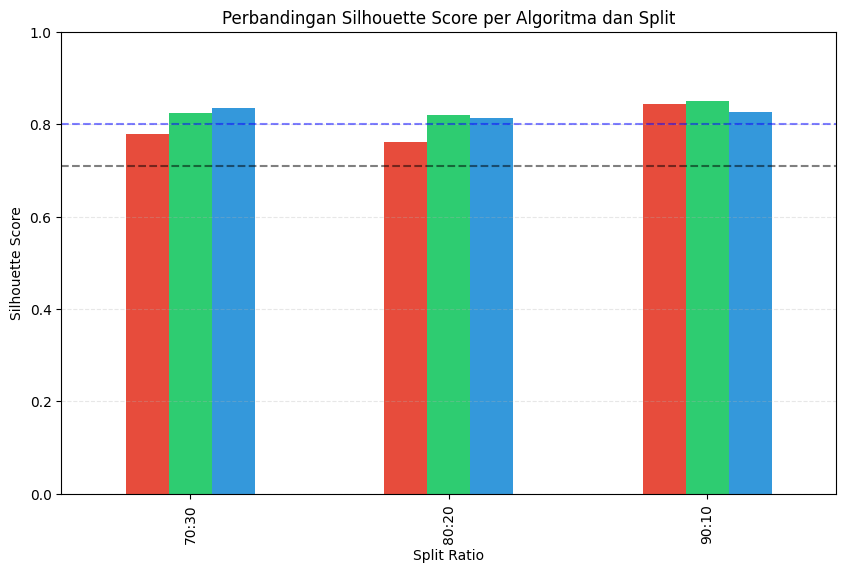

In [57]:
# Tahap 8: Model Comparison
df_final = pd.DataFrame(final_scores)

print("="*75)
print("TABEL PERBANDINGAN SILHOUETTE SCORE AKHIR")
print("="*75)
print(df_final.to_string(index=False))
print("="*75)

df_final.set_index('Split Ratio').plot(kind='bar', figsize=(10,6), color=['#e74c3c', '#2ecc71', '#3498db'], legend=False)

plt.axhline(y=0.71, color='black', linestyle='--', alpha=0.5)
plt.axhline(y=0.80, color='blue', linestyle='--', alpha=0.5)

plt.title("Perbandingan Silhouette Score per Algoritma dan Split")
plt.ylabel("Silhouette Score")
plt.ylim(0, 1)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()